In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
import os
print(os.getcwd())

D:\ProJect\RythMind_final\notebooks


In [3]:
sys.path.append("D:\ProJect\RythMind_final\src")

In [4]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from dataset_1 import get_audio_features_only

features = get_audio_features_only("../data/audio")
print(features.shape)

Reading audio folder: ../data/audio
Genre folder: blues
Processing: ../data/audio\blues\blues.00000.au
Processing: ../data/audio\blues\blues.00001.au
Processing: ../data/audio\blues\blues.00002.au
Processing: ../data/audio\blues\blues.00003.au
Processing: ../data/audio\blues\blues.00004.au
Processing: ../data/audio\blues\blues.00005.au
Processing: ../data/audio\blues\blues.00006.au
Processing: ../data/audio\blues\blues.00007.au
Processing: ../data/audio\blues\blues.00008.au
Processing: ../data/audio\blues\blues.00009.au
Processing: ../data/audio\blues\blues.00010.au
Processing: ../data/audio\blues\blues.00011.au
Processing: ../data/audio\blues\blues.00012.au
Processing: ../data/audio\blues\blues.00013.au
Processing: ../data/audio\blues\blues.00014.au
Processing: ../data/audio\blues\blues.00015.au
Processing: ../data/audio\blues\blues.00016.au
Processing: ../data/audio\blues\blues.00017.au
Processing: ../data/audio\blues\blues.00018.au
Processing: ../data/audio\blues\blues.00019.au
Proc

In [7]:
def get_audio_features_only(audio_dir):
    return load_audio_features(audio_dir)

In [8]:
from dataset_1 import get_audio_features_only

features = get_audio_features_only("../data/audio")
print(features.shape)

Reading audio folder: ../data/audio
Genre folder: blues
Processing: ../data/audio\blues\blues.00000.au
Processing: ../data/audio\blues\blues.00001.au
Processing: ../data/audio\blues\blues.00002.au
Processing: ../data/audio\blues\blues.00003.au
Processing: ../data/audio\blues\blues.00004.au
Processing: ../data/audio\blues\blues.00005.au
Processing: ../data/audio\blues\blues.00006.au
Processing: ../data/audio\blues\blues.00007.au
Processing: ../data/audio\blues\blues.00008.au
Processing: ../data/audio\blues\blues.00009.au
Processing: ../data/audio\blues\blues.00010.au
Processing: ../data/audio\blues\blues.00011.au
Processing: ../data/audio\blues\blues.00012.au
Processing: ../data/audio\blues\blues.00013.au
Processing: ../data/audio\blues\blues.00014.au
Processing: ../data/audio\blues\blues.00015.au
Processing: ../data/audio\blues\blues.00016.au
Processing: ../data/audio\blues\blues.00017.au
Processing: ../data/audio\blues\blues.00018.au
Processing: ../data/audio\blues\blues.00019.au
Proc

In [7]:
import os

audio_path = "../data/audio"

print("Genres:", os.listdir(audio_path)[:5])

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop']


In [ ]:
from vae import VAE
import torch

model = VAE(input_dim=features.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

data = torch.tensor(features, dtype=torch.float32)

for epoch in range(30):
    optimizer.zero_grad()
    recon, mu = model(data)
    loss = ((recon - data)**2).mean()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

In [10]:
from vae_1 import VAE
import torch

model = VAE(input_dim=features.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

data = torch.tensor(features, dtype=torch.float32)

for epoch in range(30):
    optimizer.zero_grad()
    recon, mu = model(data)
    loss = ((recon - data)**2).mean()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 2.4511997658196345e+19
Epoch: 5 Loss: 5.393637137673775e+19
Epoch: 10 Loss: 8.80530363111388e+18
Epoch: 15 Loss: 3.8900506985947464e+18
Epoch: 20 Loss: 2.901710416625271e+18
Epoch: 25 Loss: 4.965126230199239e+18


In [11]:
with torch.no_grad():
    _, latent = model(data)

latent = latent.numpy()
print(latent.shape)

(1000, 8)


In [20]:
labels_vae = apply_kmeans(latent)

pca_features = apply_pca(features)
labels_pca = apply_kmeans(pca_features)

In [22]:
from evaluation_1 import evaluate

vae_sil, vae_ch = evaluate(latent, labels_vae)
pca_sil, pca_ch = evaluate(pca_features, labels_pca)

print("VAE:", vae_sil, vae_ch)
print("PCA:", pca_sil, pca_ch)

VAE: 0.3570539057254791 917.5200441367425
PCA: 0.3866002857685089 1168.7493530357171


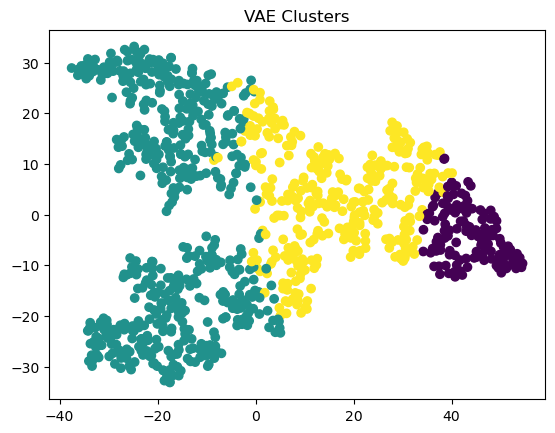

In [26]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)
vis = tsne.fit_transform(latent)

plt.scatter(vis[:,0], vis[:,1], c=labels_vae)
plt.title("VAE Clusters")
plt.savefig("../results/latent_visualization/vae.png")
plt.show()

In [24]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

import warnings
warnings.filterwarnings("ignore")

from clustering_1 import apply_kmeans, apply_pca

labels_vae = apply_kmeans(latent, n_clusters=3)

print("VAE clustering done ")

pca_features = apply_pca(features, n_components=8)
labels_pca = apply_kmeans(pca_features, n_clusters=3)

print("PCA clustering done ")

print("VAE labels shape:", labels_vae.shape)
print("PCA labels shape:", labels_pca.shape)

VAE clustering done 
PCA clustering done 
VAE labels shape: (1000,)
PCA labels shape: (1000,)


In [25]:
from evaluation_1 import evaluate

vae_sil, vae_ch = evaluate(latent, labels_vae)
pca_sil, pca_ch = evaluate(pca_features, labels_pca)

print("VAE:", vae_sil, vae_ch)
print("PCA:", pca_sil, pca_ch)

VAE: 0.3570539057254791 917.5200441367425
PCA: 0.3866002857685089 1168.7493530357171


In [27]:
import pandas as pd
import os

os.makedirs("../results/latent_visualization", exist_ok=True)

# data
results = [
    {"method": "VAE", "silhouette_score": vae_sil, "ch_score": vae_ch},
    {"method": "PCA", "silhouette_score": pca_sil, "ch_score": pca_ch}
]

df = pd.DataFrame(results)

# save
df.to_csv("../results/clustering_metrics.csv", index=False)

print("CSV saved ")

CSV saved 
